# Lab 7/8: Event Horizon Telescope Data
**Names**: Leo Quintana, Marcos Marroquin

**Course:** Physics 434 - Data Analysis Lab  
**Objective:** In this lab we explore real Event Horizon Telescope interferometry data. Our goal is to understand the statistical differences between uncalibrated and calibrated visibilities, and to test different methods for transforming raw visibility amplitudes into calibrated ones. We apply quantile mapping, Gaussian distribution fitting, and a simple neural network model to see how well each method predicts calibrated amplitudes.



### Loading in the EHT dataset 
Here we use ehtim instead of the eats library recommend as it was much easier to work with, we take a look at the variable list and other important features of both dataset summary.

We transform the data into a pandas dataframe for easier plotting to compare the variable/metrics.

In [1]:
import sys
import ehtim as eh
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Welcome to eht-imaging! v 1.2.10 



In [2]:
calibrated_file = 'SR1_M87_2017_101_lo_hops_netcal_StokesI.uvfits'
# Load uncalibrated data from uvfits file
obs_cal = eh.obsdata.load_uvfits(calibrated_file)
print(f"Source: {obs_cal.source}")
print(f"Observation frequency: {obs_cal.rf/1e9:.1f} GHz")
print(f"Observation time: {obs_cal.mjd} MJD")
print(f"Number of data points: {len(obs_cal.data)}")
print(f"Data columns: {list(obs_cal.data.dtype.names)}")

# load calibrated data from uvfits file
uncalibrated_file = 'EHT2017_3601_Stage1/hops_3601_M87+avg.uvfits'
obs_uncal = eh.obsdata.load_uvfits(uncalibrated_file)
print(f"Source: {obs_uncal.source}")
print(f"Observation frequency: {obs_uncal.rf/1e9:.1f} GHz")
print(f"Observation time: {obs_uncal.mjd} MJD")
print(f"Number of data points: {len(obs_uncal.data)}")
print(f"Data columns: {list(obs_uncal.data.dtype.names)}")

# Convert data to pandas DataFrame
cal_df = pd.DataFrame(obs_cal.data)
uncal_df = pd.DataFrame(obs_uncal.data)
 



Loading uvfits:  SR1_M87_2017_101_lo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Source: M87
Observation frequency: 227.1 GHz
Observation time: 57854 MJD
Number of data points: 7447
Data columns: ['time', 'tint', 't1', 't2', 'tau1', 'tau2', 'u', 'v', 'vis', 'qvis', 'uvis', 'vvis', 'sigma', 'qsigma', 'usigma', 'vsigma']
Loading uvfits:  EHT2017_3601_Stage1/hops_3601_M87+avg.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
Source: M87
Observation frequency: 227.1 GHz
Observation time: 57854 MJD
Number of data points: 7646
Data columns: ['time', 'tint', 't1', 't2', 'tau1', 'tau2', 'u', 'v', 'vis', 'qvis', 'uvis', 'vvis', 'sigma', 'qsigma', 'usigma', 'vsigma']


## Creating the plots for our features in our EHT dataset
**In the follow work we'll investigated the featues and do the following:**
* We plot to compare SNR distributions, visibility amplitude histograms, and calibration quality metrics.
* Take a look at the visability amplitudes as that is what my group was interested on investigating further
* We'll try fitting statistical distributions of visibility amplitudes for both datasets
* Find a statistical transformation between uncalibrated and calibrated data
* Apply Neural Networks to see its capabilities and accuracy on this super cool data


### The next few plots are to visualize and compared the features of the Calibrated and Uncalibrated data:
We aren't very interest in the exact comparison of features besides the one we will go in depth into later. These graphs along with understanding radio interferometry and our paper "EHT-HOPS Pipeline for Millimeter VLBI Data Reduction" allow us to deeply understand our dataset before looking more in depth on the visability amplitudes.

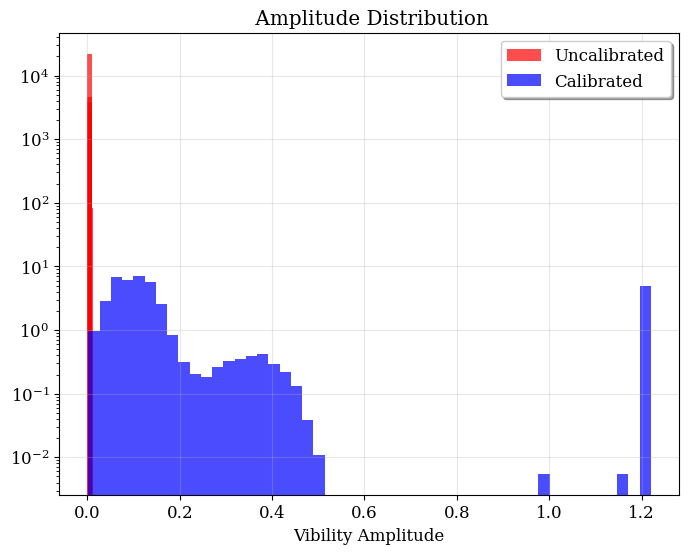

In [3]:
# calculate visibility amplitudes
uncal_amp = np.abs(uncal_df['vis']) 
cal_amp = np.abs(cal_df['vis'])

# plot histograms comparing visibility amplitudes
fig,ax = plt.subplots(figsize=(8,6))
ax.hist(uncal_amp, bins=50, alpha=0.7, density = True, label='Uncalibrated', color = 'red', width = .01)
ax.hist(cal_amp, bins=50, alpha=0.7, density = True, label = 'Calibrated', color ='blue' )
ax.set_yscale('log')
ax.set_title(' Amplitude Distribution')
ax.set_xlabel('Vibility Amplitude')
ax.grid(True, alpha=0.3)
ax.legend(shadow=True);

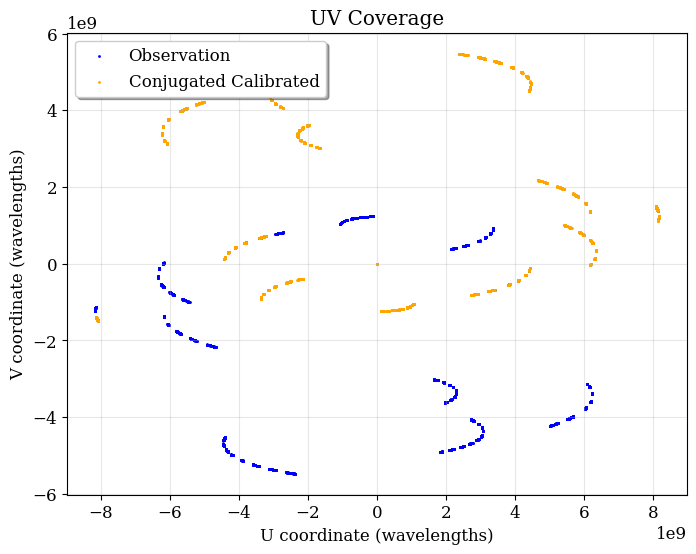

In [4]:
cal_v = cal_df['v']
cal_u = cal_df['u']

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(cal_u, cal_v, s=1, color='blue', label='Observation')
ax.scatter(-cal_u, -cal_v, s=1, color='orange', label='Conjugated Calibrated')
ax.set_title("UV Coverage")
ax.set_xlabel("U coordinate (wavelengths)")
ax.set_ylabel("V coordinate (wavelengths)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.legend(shadow=True);


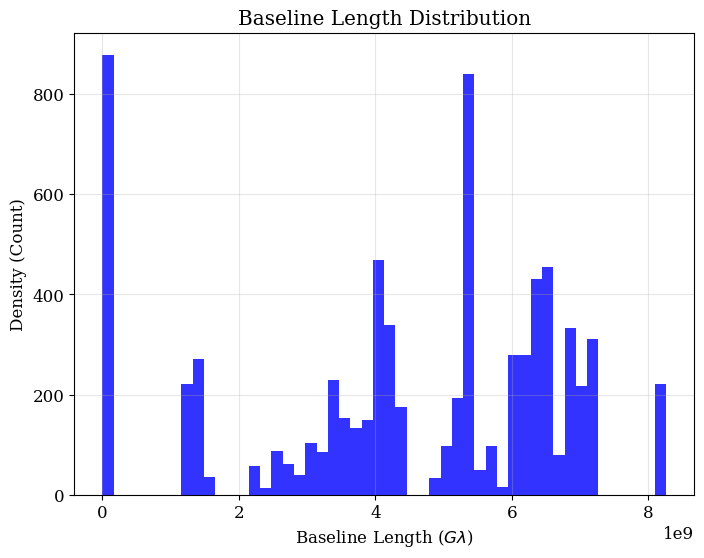

In [5]:
# calculate baseline lengths from antenna/dishes
baseline_lengths = np.sqrt(cal_u**2 + cal_v**2)

# plot histogram of baseline lengths
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(baseline_lengths, bins =50, color='blue',alpha = 0.8)
ax.set_title("Baseline Length Distribution")
ax.set_xlabel(r'Baseline Length ($G\lambda$)')
ax.set_ylabel(r'Density (Count)')
ax.grid(True, alpha=0.3)

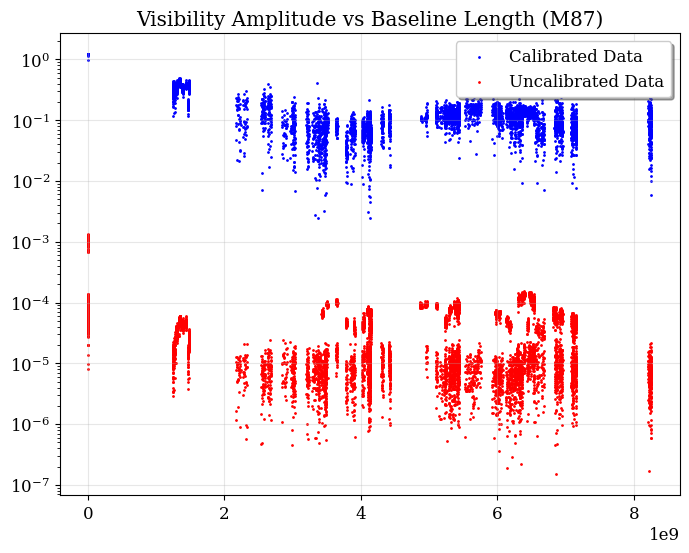

In [6]:
# find baseline lengths for uncalibrated data
uncal_v = uncal_df['v']
uncal_u = uncal_df['u']
uncal_baseline_lengths = np.sqrt(uncal_u**2 + uncal_v**2)

# plot visibility amplitude vs baseline length
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(baseline_lengths, cal_amp, s=1, color='blue', label='Calibrated Data')
ax.set_title("Visibility Amplitude vs Baseline Length (M87)")
ax.scatter(uncal_baseline_lengths, uncal_amp, s=1, color='red', label='Uncalibrated Data')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right',shadow=True);

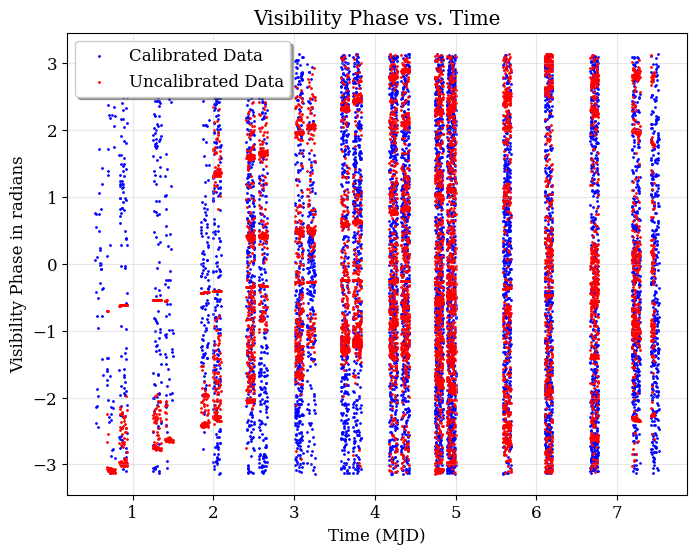

In [7]:

times_cal = obs_cal.data['time']  # in MJD
times_uncal = obs_uncal.data['time']  # in MJD
phases_cal = np.angle(obs_cal.data['vis'])  # in radians
phases_uncal = np.angle(obs_uncal.data['vis'])  # in radians

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(times_uncal, phases_uncal, s=1, color='blue', label='Calibrated Data')
ax.scatter(times_cal, phases_cal, s=1, color='red', label='Uncalibrated Data')
ax.set_title('Visibility Phase vs. Time')
ax.set_xlabel('Time (MJD)')
ax.set_ylabel('Visibility Phase in radians')
ax.grid(True, alpha=0.3)
ax.legend(shadow = True);

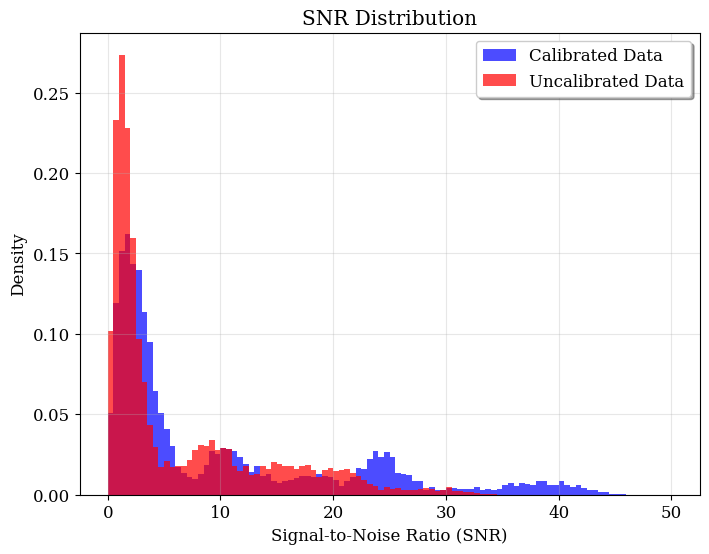

In [8]:
snr_cal = np.abs(obs_cal.data['vis']) / obs_cal.data['sigma']  # SNR for calibrated data
snr_uncal = np.abs(obs_uncal.data['vis']) / obs_uncal.data['sigma']  # SNR for uncalibrated data
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(snr_cal, bins=100, color='blue', alpha=0.7, label='Calibrated Data', density=True, range =(0,50)) 
ax.hist(snr_uncal, bins=100, color='red', alpha=0.7, label='Uncalibrated Data', density=True, range =(0,50))
ax.set_title('SNR Distribution')
ax.set_xlabel('Signal-to-Noise Ratio (SNR)')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3)
ax.legend(shadow=True);

We see calibrated data has much higher SNR and visibility amplitude with less valid points

### Here we have a side by side comparison of Calibrated and Uncalibrated Amplitude Distribution
We can use this to refer back to as visualization after fitting and transformation through quantile mapping and ML

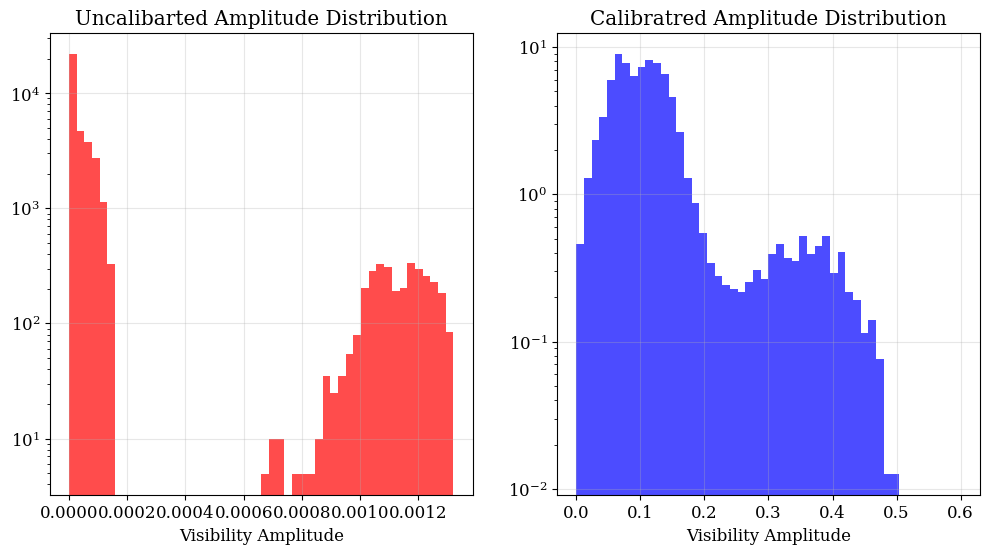

In [9]:
# Split the visbitility amplitudes into tow different plots calibrated and uncalibrated
fig,ax = plt.subplots(1,2, figsize=(12,6))
ax[0].hist(uncal_amp, bins=50, alpha=0.7, density = True, label='Uncalibrated', color = 'red')
ax[0].set_yscale('log')
ax[0].set_xlabel('Visibility Amplitude')
ax[0].set_title('Uncalibarted Amplitude Distribution')
ax[0].grid(True, alpha=0.3)

ax[1].hist(cal_amp, bins=50, alpha=0.7, range = (0,0.6), density = True, label = 'Calibrated', color ='blue' )
ax[1].set_yscale('log')
ax[1].set_title('Calibratred Amplitude Distribution')
ax[1].set_xlabel('Visibility Amplitude')
ax[1].grid(True, alpha=0.3)

 

## Finding best fit Gaussians onto the Calibrated and Uncalibrated Distributions
By doing this we  get an idea of the underlying distributions 
Even though visibility amplitudes technically follow a Rician like distribution, Gaussian fits still give useful summary statistics. The calibrated amplitudes show much higher variance, which reflects their wider dynamic range after gain calibration.

Uncalibrated Gaussian 1: mu = 0.000031, std = 0.000034, a = 0.9159
Uncalibrated Gaussian 2: mu = 0.001129, std = 0.000106, a = 0.0604
Calibrated Gaussian 1: mu = 0.100159, std = 0.041891, a = 0.8186
Calibrated Gaussian 2: mu = 0.355867, std = 0.055501, a = 0.0634


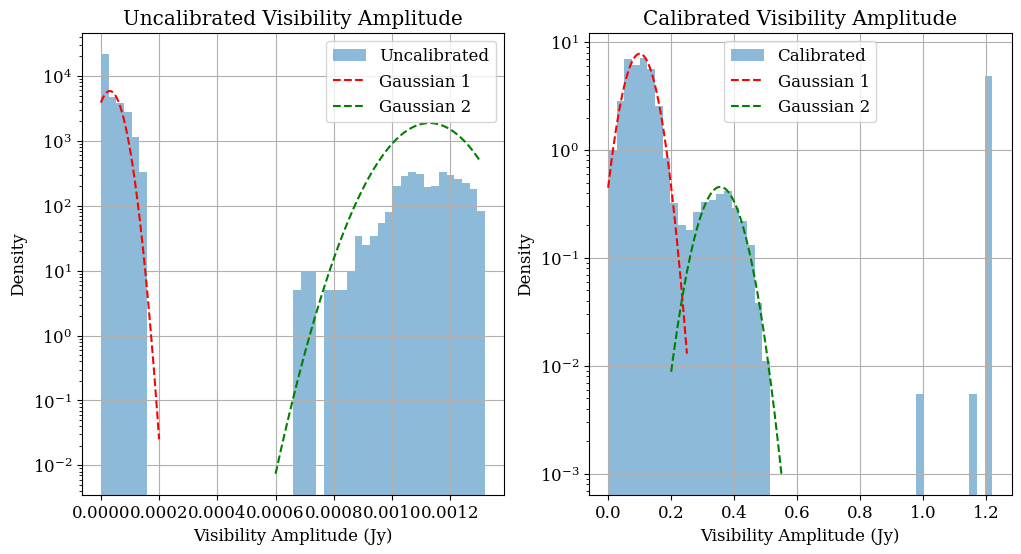

In [10]:
# Fit two gaussians to calibrated and uncalibrated histograms
# Here we use the scipy.stats.norm module to fit gaussian distributions
from scipy.stats import norm

# Define a function to fit a gaussian
def gaussian_fit(x, mu, std, a):
    return a * norm.pdf(x, mu, std)

# Fit two gaussians to the uncalibrated data
uncal_gauss1_mu, uncal_gauss1_std = norm.fit(uncal_amp[uncal_amp < 0.0002])
uncal_gauss2_mu, uncal_gauss2_std = norm.fit(uncal_amp[uncal_amp >= 0.0002])

# Fit two gaussians to the calibrated data
calib_gauss1_mu, calib_gauss1_std = norm.fit(cal_amp[cal_amp < 0.25])
calib_gauss2_mu, calib_gauss2_std = norm.fit(cal_amp[(cal_amp >= 0.25) & (cal_amp < 0.55)])

# Find amplitudes for calibrated and uncalibrated gaussians
calib_gauss1_a = len(cal_amp[cal_amp < 0.25]) / len(cal_amp)
calib_gauss2_a = len(cal_amp[(cal_amp >= 0.25) & (cal_amp < 0.55)]) / len(cal_amp)  

uncal_gauss1_a = len(uncal_amp[uncal_amp < 0.0002]) / len(uncal_amp)
uncal_gauss2_a = len(uncal_amp[(uncal_amp >= 0.0002) & (uncal_amp < 0.0012)]) / len(uncal_amp)

# Print fitted parameters
print("Uncalibrated Gaussian 1: mu = {:.6f}, std = {:.6f}, a = {:.4f}".format(uncal_gauss1_mu, uncal_gauss1_std, uncal_gauss1_a))
print("Uncalibrated Gaussian 2: mu = {:.6f}, std = {:.6f}, a = {:.4f}".format(uncal_gauss2_mu, uncal_gauss2_std, uncal_gauss2_a))
print("Calibrated Gaussian 1: mu = {:.6f}, std = {:.6f}, a = {:.4f}".format(calib_gauss1_mu, calib_gauss1_std, calib_gauss1_a))
print("Calibrated Gaussian 2: mu = {:.6f}, std = {:.6f}, a = {:.4f}".format(calib_gauss2_mu, calib_gauss2_std, calib_gauss2_a))

# Plot the fitted gaussians for uncalibrated data
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
x_uncal1 = np.linspace(0, 0.0002, 1000)
x_uncal2 = np.linspace(0.0006, 0.0013, 1000)
ax[0].hist(uncal_amp, bins=50, density=True, alpha=0.5, label='Uncalibrated')
ax[0].plot(x_uncal1, gaussian_fit(x_uncal1, uncal_gauss1_mu, uncal_gauss1_std, 0.5), 'r--', label='Gaussian 1')
ax[0].plot(x_uncal2, gaussian_fit(x_uncal2, uncal_gauss2_mu, uncal_gauss2_std, 0.5), 'g--', label='Gaussian 2')
ax[0].set_yscale('log')
ax[0].set_xlabel('Visibility Amplitude (Jy)')
ax[0].set_ylabel('Density')
ax[0].set_title('Uncalibrated Visibility Amplitude')
ax[0].grid()
ax[0].legend()

# Plot the fitted gaussians for calibrated data
x_calib1 = np.linspace(0, 0.25, 1000)
x_calib2 = np.linspace(0.2, 0.55, 1000)
ax[1].hist(cal_amp, bins=50, density=True, alpha=0.5, label='Calibrated')
ax[1].plot(x_calib1, gaussian_fit(x_calib1, calib_gauss1_mu, calib_gauss1_std, calib_gauss1_a), 'r--', label='Gaussian 1')
ax[1].plot(x_calib2, gaussian_fit(x_calib2, calib_gauss2_mu, calib_gauss2_std, calib_gauss2_a), 'g--', label='Gaussian 2')
ax[1].set_yscale('log')
ax[1].set_xlabel('Visibility Amplitude (Jy)')
ax[1].set_ylabel('Density')
ax[1].set_title('Calibrated Visibility Amplitude')
ax[1].grid()
ax[1].legend();

We get pretty good gaussian distributions fitted to our datasets

## We must create a method of finding the quantile mapping from one distribution of data to another and residual RMS to find an optimal transformation from our Uncalibrated to Calibrated data

Quantile mapping works well because it doesn’t assume any particular functional form between raw and calibrated amplitudes. In practice, it partially corrects the amplitude compression, but still shows mismatch at higher amplitudes.

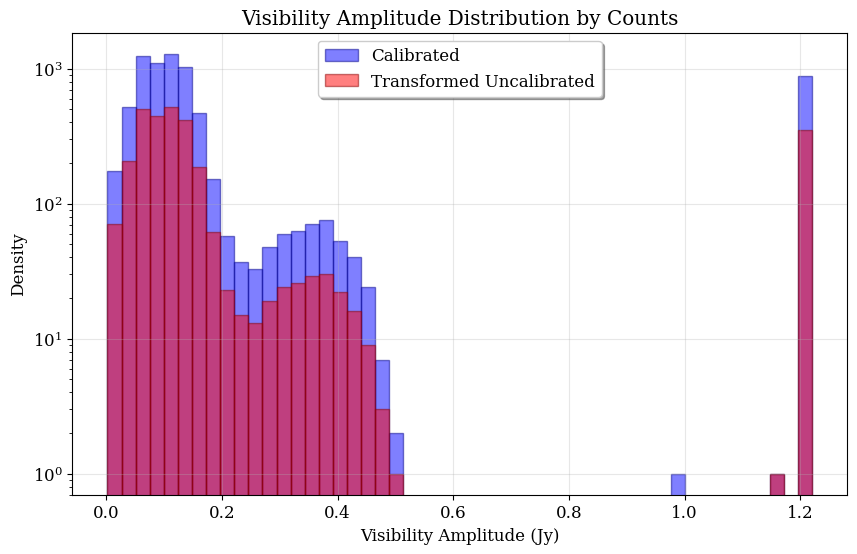

In [11]:
import numpy as np
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# create a function to transform uncalibrated visibility amplitudes to calibrated amplitudes
def transform_uncalibrated_to_calibrated(uncal_amp, uncal_sigma, cal_amp):
    # calculate SNR and apply EHT threshold from paper
    uncal_snr = uncal_amp / (uncal_sigma)
    quality_mask = uncal_snr > 7.0 # this is SNR threshold of 7 used in 2017 EHT paper
    filtered_uncal = uncal_amp[quality_mask]
        
    # quantile mapping to match uncalibrated to calibrated distribution
    def quantile_map(source, target):
        
        source_sorted = np.sort(source)  # ordered versions of both datasets from smallest to largest values.
        target_sorted = np.sort(target)  # cumulative distribution
        
        source_ranks = np.searchsorted(source_sorted, source, side='left') # for each point in the original source data, find its rank position in the sorted array.
        target_quantiles = np.linspace(0, 1, len(target_sorted))  # uniformly spaced quantiles for the target data.
        source_ranks = np.clip(source_ranks, 0, len(source_sorted) - 1) #ensure ranks are within valid bounds.
        source_quantiles = source_ranks / (len(source_sorted) - 1) # convert ranks to quantiles between 0 and 1.
        transformed = np.interp(source_quantiles, target_quantiles, target_sorted) # map source quantiles to target values using interpolation.
        return transformed 
    
    transformed = quantile_map(filtered_uncal, cal_amp) # transform snr filtered uncalibrated data
    return cal_amp, transformed

# extract data and transform to arrays
cal_amp = np.abs(cal_df["vis"].values)
uncal_amp = np.abs(uncal_df["vis"].values)
cal_sigma = cal_df["sigma"].values
uncal_sigma = uncal_df["sigma"].values
# use our function
cal_data, transformed_uncal = transform_uncalibrated_to_calibrated(
    uncal_amp, uncal_sigma, cal_amp)

# plot the newly transformed uncalibrated and the calibrated distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(cal_data, bins=50, alpha=0.5, density=False, 
        label='Calibrated', color='blue', edgecolor='darkblue')
ax.hist(transformed_uncal, bins=50, alpha=0.5, density=False,
        label='Transformed Uncalibrated', color='red', edgecolor='darkred')
ax.set_yscale('log')
ax.set_xlabel('Visibility Amplitude (Jy)')
ax.set_ylabel('Density')
ax.set_title('Visibility Amplitude Distribution by Counts')
ax.legend(shadow=True);
ax.grid(True, alpha=0.3)

Propotionally looks very good comparing to the orignal calibrated distribution.

The lowest RMS residual is 0.0030 at SNR threshold 7.44


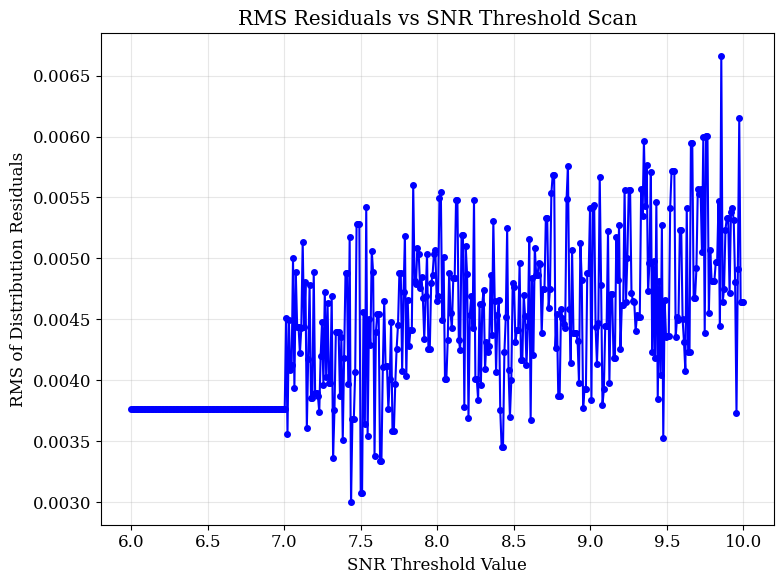

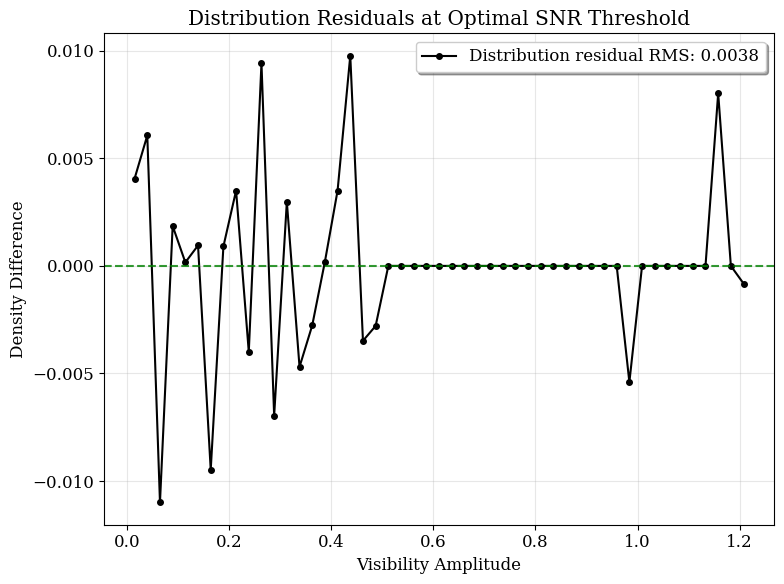

In [12]:
# scan over residuals to find minimum
residual_scanvalues = np.linspace(6,10, 444)
residuals = []

def distribution_residuals(data1, data2):
        # use same bin edges for both histograms
        min_val = min(np.min(data1), np.min(data2))
        max_val = max(np.max(data1), np.max(data2))
        bins = np.linspace(min_val, max_val, 50)
        
        # Get histogram counts
        counts1 ,_ = np.histogram(data1, bins=bins, density=True)
        counts2 ,_ = np.histogram(data2, bins=bins, density=True)
        
        # calculate residuals as difference in densities
        residuals = counts2 - counts1  # transformed - calibrated
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        return bin_centers, residuals

for cut in residual_scanvalues:
    # apply SNR cut to uncalibrated data
    snr_mask = (uncal_amp / uncal_sigma) > cut
    filtered_uncal_amp = uncal_amp[snr_mask]
    # transform filtered uncalibrated data
    _, transformed_filtered_uncal = transform_uncalibrated_to_calibrated(
        filtered_uncal_amp, uncal_sigma[snr_mask], cal_amp)
    # calculate residuals
    _, resid = distribution_residuals(cal_data, transformed_filtered_uncal)
    # compute RMS of residuals as significance metric
    rms_resid = np.sqrt(np.mean(resid**2))
    residuals.append(rms_resid)
    
# convert list to numpy array for easier handling
residuals = np.array(residuals)
# find minimum residual and corresponding SNR threshold
snr_threshold = np.argmin(residuals)
min_snr = np.min(residuals)
print(f"The lowest RMS residual is {min_snr:.4f} at SNR threshold {residual_scanvalues[snr_threshold]:.2f}")

# Plot RMS residuals vs SNR threshold
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(residual_scanvalues, residuals, 'bo-', markersize=4)
ax.set_xlabel('SNR Threshold Value')
ax.set_ylabel('RMS of Distribution Residuals')
ax.set_title('RMS Residuals vs SNR Threshold Scan')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# calculate residuals using our function and optimal SNR threshold

bin_centers, dist_resid = distribution_residuals(cal_data, transformed_uncal)

# plot distribution of residuals at the optimal SNR threshold
fig, ax = plt.subplots( figsize=(8, 6))
ax.plot(bin_centers, dist_resid, 'ko-', markersize=4, label = f"Distribution residual RMS: {np.sqrt(np.mean(dist_resid**2)):.4f}")
ax.axhline(y=0, color='green', linestyle='--', alpha=0.8)
ax.set_xlabel('Visibility Amplitude')
ax.set_ylabel('Density Difference')
ax.set_title('Distribution Residuals at Optimal SNR Threshold')
ax.grid(True, alpha=0.3)
ax.legend(shadow=True);
plt.tight_layout()
plt.show()




We are able to find the most optimal SNR threshold using residual optimization scans from our assumption based on the paper "EHT-HOPS Pipeline for Millimeter VLBI Data Reduction" that goes over the math of there much more complex process.

### Replot the transfomration from uncalibrated to calibrated using the our optimized SNR threshold

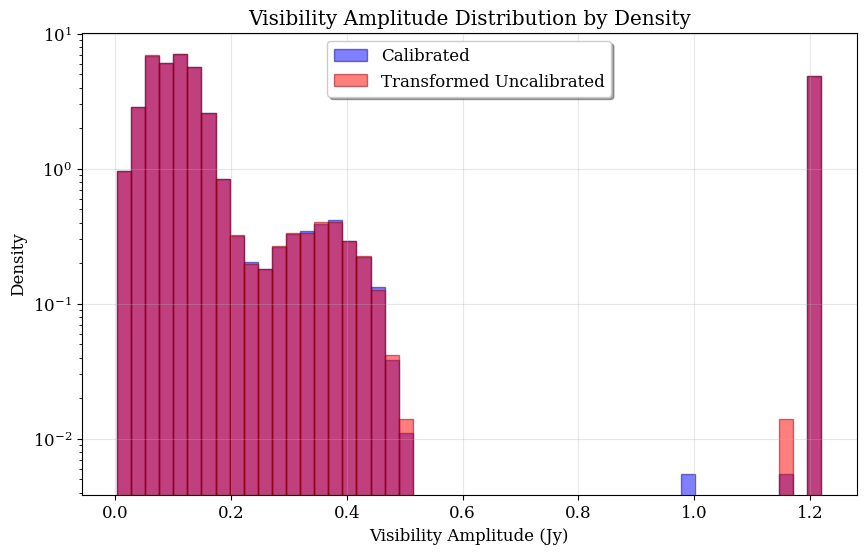

In [13]:
import numpy as np
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# create a function to transform uncalibrated visibility amplitudes to calibrated amplitudes
def transform_uncalibrated_to_calibrated(uncal_amp, uncal_sigma, cal_amp):
    # calculate SNR and apply EHT threshold from paper
    uncal_snr = uncal_amp / (uncal_sigma)
    quality_mask = uncal_snr > 7.43
    filtered_uncal = uncal_amp[quality_mask]
        
    # quantile mapping to match uncalibrated to calibrated distribution
    def quantile_map(source, target):
        
        source_sorted = np.sort(source)  # ordered versions of both datasets from smallest to largest values.
        target_sorted = np.sort(target)  # cumulative distribution
        
        source_ranks = np.searchsorted(source_sorted, source, side='left') # for each point in the original source data, find its rank position in the sorted array.
        target_quantiles = np.linspace(0, 1, len(target_sorted))  # uniformly spaced quantiles for the target data.
        source_ranks = np.clip(source_ranks, 0, len(source_sorted) - 1) #ensure ranks are within valid bounds.
        source_quantiles = source_ranks / (len(source_sorted) - 1) # convert ranks to quantiles between 0 and 1.
        transformed = np.interp(source_quantiles, target_quantiles, target_sorted) # map source quantiles to target values using interpolation.
        return transformed 
    
    transformed = quantile_map(filtered_uncal, cal_amp) # transform snr filtered uncalibrated data
    return cal_amp, transformed

# extract data and transform to arrays
cal_amp = np.abs(cal_df["vis"].values)
uncal_amp = np.abs(uncal_df["vis"].values)
cal_sigma = cal_df["sigma"].values
uncal_sigma = uncal_df["sigma"].values
# use our function
cal_data, transformed_uncal = transform_uncalibrated_to_calibrated(
    uncal_amp, uncal_sigma, cal_amp)

# plot the newly transformed uncalibrated and the calibrated distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(cal_data, bins=50, alpha=0.5, density=True, 
        label='Calibrated', color='blue', edgecolor='darkblue')
ax.hist(transformed_uncal, bins=50, alpha=0.5, density=True,
        label='Transformed Uncalibrated', color='red', edgecolor='darkred')
ax.set_yscale('log')
ax.set_xlabel('Visibility Amplitude (Jy)')
ax.set_ylabel('Density')
ax.set_title('Visibility Amplitude Distribution by Density')
ax.legend(shadow=True);
ax.grid(True, alpha=0.3)

We don't really see a significant change, almost completely matches with the SNR threshold found in the paper, and concludes that our transformation found from quantile mapping works well.


## Stastical Transformation Conclusions:
We were able to find a transformation for our uncalibrated data to calibrated data through quantile mapping that mathematically and from inspection looks much more like original calibrated data provided. We were able to do this to a decently accurate degree compared to the huge data pipeline that is described in the paper "EHT-HOPS Pipeline for Millimeter VLBI Data Reduction".

## Trying Neural Network Transformation:
### Training from our uncalibrated dataset

### First we must make a new andas dataframe merging the calibrated and uncalibrated data where for times to coincide with the variable t1 and t1

In [14]:
df_cal = pd.DataFrame(obs_cal.data)
df_uncal = pd.DataFrame(obs_uncal.data)[:len(df_cal)]

# Merge df_cal and df_uncal with entries that correspond to the same baselines and times
merged = pd.merge(df_cal, df_uncal, on=['t1', 't2', 'time'], suffixes=('_cal', '_uncal'), how='inner')

# Remove tau1_cal, tau2_cal, and tau1_uncal, tau2_uncal, u_uncal, and v_uncal columns since they are redundant
merged = merged.drop(columns=['tau1_cal', 'tau2_cal', 'tau1_uncal', 'tau2_uncal', 'u_uncal', 'v_uncal'])

# Make baseline length column as u_cal^2 + v_cal^2
merged['baseline_length'] = np.sqrt(merged['u_cal']**2 + merged['v_cal']**2)

# Make SNR columns for calibrated and uncalibrated data
merged['snr_cal'] = np.abs(merged['vis_cal'].values) / merged['sigma_cal'].values
merged['snr_uncal'] = np.abs(merged['vis_uncal'].values) / merged['sigma_uncal'].values

# Make visibility amplitude columns for calibrated and uncalibrated data
merged['amp_cal'] = np.abs(merged['vis_cal'].values)
merged['amp_uncal'] = np.abs(merged['vis_uncal'].values)

display(merged.head())

,time,tint_cal,t1,t2,u_cal,v_cal,vis_cal,qvis_cal,uvis_cal,vvis_cal,...,vvis_uncal,sigma_uncal,qsigma_uncal,usigma_uncal,vsigma_uncal,baseline_length,snr_cal,snr_uncal,amp_cal,amp_uncal
0,0.534722,9.181313,AA,PV,-4.395897e+09,-4.509549e+09,-0.155228+0.009071j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000031-0.000025j,0.000005,0.000005,0.000005,0.000005,6.297614e+09,40.478674,26.949048,0.155493,0.000124
1,0.537500,9.600000,AA,PV,-4.396411e+09,-4.510217e+09,-0.166374+0.009444j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000004-0.000042j,0.000005,0.000005,0.000005,0.000005,6.298452e+09,42.857604,30.866233,0.166642,0.000141
2,0.540278,9.599808,AA,PV,-4.396951e+09,-4.510923e+09,-0.154373+0.003790j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000025-0.000036j,0.000005,0.000005,0.000005,0.000005,6.299333e+09,39.430662,24.630019,0.154420,0.000113
3,0.543056,8.800000,AA,PV,-4.397482e+09,-4.511620e+09,-0.159206+0.007453j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000045-0.000030j,0.000005,0.000005,0.000005,0.000005,6.300203e+09,38.719074,24.666971,0.159381,0.000116
4,0.545833,8.800000,AA,PV,-4.397980e+09,-4.512275e+09,-0.151957+0.008094j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000006-0.000019j,0.000004,0.000004,0.000004,0.000004,6.301020e+09,37.092763,15.972271,0.152172,0.000069


### We take a look at how diverse the data is in terms of baseline pairs which we will utilize in the train-test splitting:

Antennas used: ['AA' 'AP' 'AZ' 'JC' 'LM' 'PV' 'SM']


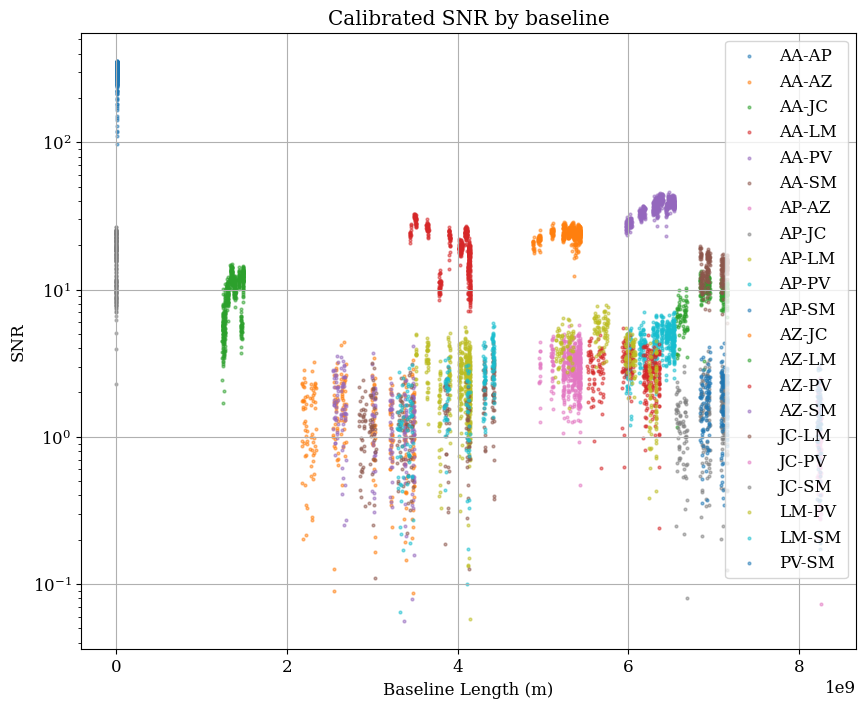

In [15]:
# Plot each different baseline pair visibilities
# N(N-1)/2 baselines for N antennas
antennas = np.unique(np.concatenate((df_cal['t1'].values, df_cal['t2'].values)))
print(f"Antennas used: {antennas}")

# Plotting calibrated visibilities for each baseline
plt.figure(figsize=(10,8))
for i in range(len(antennas)):
    for j in range(i+1, len(antennas)):
        ant1 = antennas[i]
        ant2 = antennas[j]
        
        mask = ((df_cal['t1'] == ant1) & (df_cal['t2'] == ant2)) | ((df_cal['t1'] == ant2) & (df_cal['t2'] == ant1))
        snr = np.abs(df_cal['vis'].values[mask]) / df_cal['sigma'].values[mask]
        baseline_lengths = np.sqrt(df_cal['u'].values[mask]**2 + df_cal['v'].values[mask]**2)

        plt.scatter(baseline_lengths, snr, s=4, alpha=0.5, label=f'{ant1}-{ant2}')
        plt.xlabel('Baseline Length (m)')
        plt.ylabel('SNR')
        plt.title('Calibrated SNR by baseline')
        plt.yscale('log')
        plt.grid()
        plt.legend(loc='upper right');

With this new aligned time dataset we split the dataframe into 80% training and 20% testing, but we have to take into consideration taking 80% of each baseline pair

In [16]:
# Separate 80% and 20% for training and testing relative to each baseline pair
baseline_pairs = merged.groupby(['t1', 't2'])
train_list = []
test_list = []
for name, group in baseline_pairs:
    train_size = int(0.8 * len(group))
    train_data = group.iloc[:train_size]
    test_data = group.iloc[train_size:]
    train_list.append(train_data)
    test_list.append(test_data)

print(f"Number of baseline pairs: {len(train_list)}")
print(f"First baseline pair training data sample:")
display(train_list[0].head())

print(f"First baseline pair testing data sample:")
display(test_list[0].head())

Number of baseline pairs: 21
First baseline pair training data sample:


,time,tint_cal,t1,t2,u_cal,v_cal,vis_cal,qvis_cal,uvis_cal,vvis_cal,...,vvis_uncal,sigma_uncal,qsigma_uncal,usigma_uncal,vsigma_uncal,baseline_length,snr_cal,snr_uncal,amp_cal,amp_uncal
37,0.684722,9.588737,AA,AP,805263.3750,-1692975.375,0.916520-0.790486j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000270+0.000068j,0.000004,0.000004,0.000004,0.000004,1.874731e+06,306.080227,286.796458,1.210321,0.001285
40,0.687500,9.600000,AA,AP,805043.1250,-1692852.000,0.917772-0.789544j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000266+0.000009j,0.000004,0.000004,0.000004,0.000004,1.874525e+06,306.846298,289.918396,1.210655,0.001272
42,0.690278,4.000000,AA,AP,804872.8125,-1692756.625,0.919471-0.787207j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000263+0.000069j,0.000007,0.000007,0.000007,0.000007,1.874365e+06,193.501393,185.335007,1.210422,0.001259
78,0.834722,9.158183,AA,AP,792515.8125,-1686223.250,0.981776-0.708244j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000460-0.000042j,0.000004,0.000004,0.000004,0.000004,1.863177e+06,313.914236,275.214679,1.210576,0.001237
82,0.837500,10.000000,AA,AP,792270.6875,-1686100.500,0.982097-0.707489j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000453+0.000129j,0.000004,0.000004,0.000004,0.000004,1.862962e+06,321.699926,288.050305,1.210394,0.001238


First baseline pair testing data sample:


,time,tint_cal,t1,t2,u_cal,v_cal,vis_cal,qvis_cal,uvis_cal,vvis_cal,...,vvis_uncal,sigma_uncal,qsigma_uncal,usigma_uncal,vsigma_uncal,baseline_length,snr_cal,snr_uncal,amp_cal,amp_uncal
5088,4.981944,9.195424,AA,AP,66756.789062,-1574605.500,1.157448-0.354260j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000807-0.000273j,0.000004,0.000004,0.000004,0.000004,1.576020e+06,327.587920,252.220858,1.210448,0.001130
5107,4.984722,7.993822,AA,AP,66078.703125,-1574594.250,1.157347-0.354501j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000839-0.000197j,0.000005,0.000005,0.000005,0.000005,1.575980e+06,304.266265,233.673978,1.210422,0.001123
5128,4.987500,8.798617,AA,AP,65498.250000,-1574584.625,1.157236-0.354762j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000744-0.000370j,0.000004,0.000004,0.000004,0.000004,1.575946e+06,311.773503,243.925133,1.210393,0.001093
5152,4.990278,9.198334,AA,AP,64849.027344,-1574574.125,1.157058-0.355631j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,0.000018-0.000794j,0.000004,0.000004,0.000004,0.000004,1.575909e+06,323.644672,233.610005,1.210478,0.001047
5169,4.993055,9.198626,AA,AP,64248.289062,-1574564.375,1.156919-0.355832j,0.0+0.0j,0.0+0.0j,0.0+0.0j,...,-0.000180-0.000822j,0.000004,0.000004,0.000004,0.000004,1.575875e+06,320.129024,246.707071,1.210404,0.001106


## We train a simple fully-connected network from our uncalibrated dataset to try to predict SNR and amplitudes based on the baseline distance:

In [17]:

# Simple FC Network
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class FCNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FCNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [18]:
# open neural network model and train on training data
model = FCNet(input_size=3, hidden_size=16, output_size=3)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# combine all training and testing data
train_data = pd.concat(train_list)
test_data = pd.concat(test_list)

# convert training data to tensors
train_inputs = torch.tensor(train_data[['baseline_length', 'snr_uncal', 'amp_uncal']].values, dtype=torch.float32)
train_targets = torch.tensor(train_data[['baseline_length', 'snr_cal', 'amp_cal']].values, dtype=torch.float32)


# normalize inputs and targets
input_mean = train_inputs.mean(dim=0)
input_std = train_inputs.std(dim=0)
train_inputs = (train_inputs - input_mean) / input_std

target_mean = train_targets.mean(dim=0)
target_std = train_targets.std(dim=0)
train_targets = (train_targets - target_mean) / target_std

# training loop
num_epochs = len(train_data)
train_loss_values = []

# create dataset + loader
dataset = TensorDataset(train_inputs, train_targets)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# training
num_epochs = 200
train_loss_values = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for x, y in loader:
        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss_values.append(epoch_loss)

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")
    

Epoch 20/200, Loss: 1.5562
Epoch 40/200, Loss: 0.6778
Epoch 60/200, Loss: 0.5630
Epoch 80/200, Loss: 0.5230
Epoch 100/200, Loss: 0.5008
Epoch 120/200, Loss: 0.4864
Epoch 140/200, Loss: 0.4727
Epoch 160/200, Loss: 0.4640
Epoch 180/200, Loss: 0.4600
Epoch 200/200, Loss: 0.4563


In [19]:
# evaluate on test data
model.eval()
test_inputs = torch.tensor(test_data[['baseline_length', 'snr_uncal', 'amp_uncal']].values, dtype=torch.float32)
test_targets = torch.tensor(test_data[['baseline_length', 'snr_cal', 'amp_cal']].values, dtype=torch.float32)

# normalize test inputs and targets
test_inputs = (test_inputs - input_mean) / input_std
test_targets = (test_targets - target_mean) / target_std

test_loss_values = []
with torch.no_grad():
    test_outputs = model(test_inputs)
    test_loss = nn.MSELoss(reduction='none')(test_outputs, test_targets)
    test_loss_values.append(test_loss.numpy())

In [20]:
# Plot loss values for train and test data
print(test_inputs)
print(test_outputs)

tensor([[-1.9104,  3.3813,  3.3005],
        [-1.9104,  3.1036,  3.2767],
        [-1.9104,  3.2571,  3.1784],
        ...,
        [ 1.6080, -0.3784, -0.3846],
        [ 1.6077, -0.3660, -0.3724],
        [ 1.6074, -0.3571, -0.3652]])
tensor([[-1.9163,  3.3683,  2.6634],
        [-1.9164,  3.1314,  2.6642],
        [-1.9142,  3.3311,  2.6641],
        ...,
        [ 1.6140, -0.4111, -0.4863],
        [ 1.6139, -0.3975, -0.4850],
        [ 1.6142, -0.3878, -0.4827]])


### We can now plot the SNR predictions made from the NN we just trained

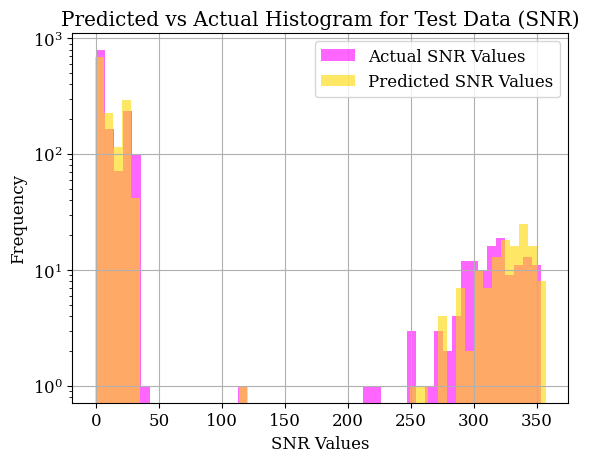

In [21]:
# Convert tensors back to numpy for plotting
test_inputs_np = test_inputs.numpy()
test_outputs_np = test_outputs.numpy()
test_targets_np = test_targets.numpy()

# Scale back to original values
test_outputs_np = test_outputs_np * target_std.numpy() + target_mean.numpy()
test_targets_np = test_targets_np * target_std.numpy() + target_mean.numpy()

# Plot predicted vs actual histogram test data SNR only
plt.hist(test_targets_np[:, 1], bins=50, alpha=0.6, label='Actual SNR Values', color = 'magenta')
plt.hist(test_outputs_np[:, 1], bins=50, alpha=0.6, label='Predicted SNR Values', color = 'gold')
plt.xlabel('SNR Values')
plt.ylabel('Frequency')
plt.title('Predicted vs Actual Histogram for Test Data (SNR)')
plt.legend()
plt.grid()
plt.yscale('log')

From inspection, the neural network was pretty accurate in predicting the corresponding SNR values from our test data.

### Next the amplitude predictions made from the NN

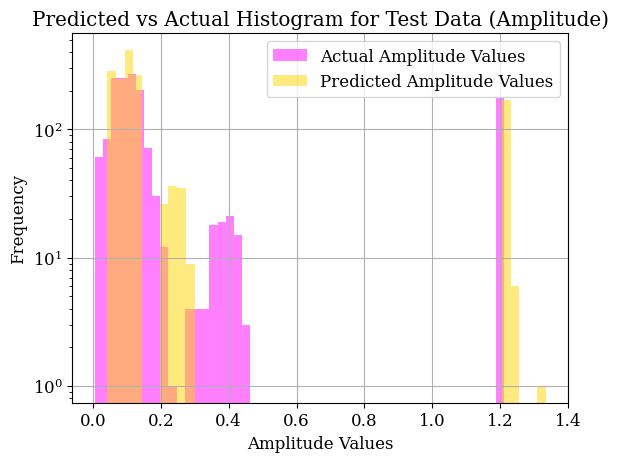

In [22]:
# Plot predicted vs actual histogram test data Amplitude only
plt.hist(test_targets_np[:, 2], bins=50, alpha=0.5, label='Actual Amplitude Values', color = 'magenta')
plt.hist(test_outputs_np[:, 2], bins=50, alpha=0.5, label='Predicted Amplitude Values', color = 'gold')
plt.xlabel('Amplitude Values')
plt.ylabel('Frequency')
plt.title('Predicted vs Actual Histogram for Test Data (Amplitude)')
plt.legend()
plt.grid()
plt.yscale('log')

From inspection of the histogram, it seems it wasn't able to acccurately predict the amplitude values from our test dataset. We can see the general shape is very similar but the frequency of amplitude values is shifted to the left.

### Conclusion on Neural Networks:
* We are easily able to train a model to transform SNR and Visability Amplitudes from uncalibrated to calibrated although the results are possibly not as great as other statistical methods like the one we did above.
* The neural network struggled because the mapping from uncalibrated to calibrated amplitude isn’t deterministic i.e. the calibration step depends on baseline dependent gain curves, it is more complex then look simply at visability amplitude.

# Overall Lab Conclusion/ Keytakeaways:

* **Uncalibrated vs Calibrated Visibility**
The uncalibrated amplitudes are heavily compressed toward zero, while the calibrated data span a much wider and smoother distribution. This highlighting how  proper gain calibration is for this analysis.

* **Quantile Mapping is a great  Statistical Transformation:**
Quantile mapping does improve the shape of the uncalibrated amplitude distribution, but it cannot fully reconstruct the correct physical scaling.

* **Gaussian Fits Show Clear Statistical Separation:**
Calibrated amplitudes have significantly higher mean and variance compared to the raw data. Even though a Gaussian isn’t the perfect model for visibilities.

* **Neural Networks doesn't Have Exact Mapping for our Data:**
A simple neural network was able to learn part of the relationship between uncalibrated and calibrated amplitudes, but the predictions were still far from perfect. This makes sense because calibration depends on more parameters than amplitude alone.

* **-Main Insight- Calibration Is Not a Simple Function of Amplitude:**
Across all methods, the biggest takeaway is that the transformation from uncalibrated to calibrated visibility amplitude is complex and baseline dependent. No singlevariable model or ML model can fully capture this mapping without additional data.
